# Phase 2: Advanced AI Pipeline, Algorithms & Model Training
**Author:** Justus Izuchukwu Onuh (Group 22)

## System Architecture & Algorithmic Approach
This notebook constructs the core machine learning engine for our e-commerce prediction system. To guarantee business utility, mathematical rigor, and architectural explainability, this phase implements the following algorithmic pipeline:

1. **Core Algorithm (Explainable AI):** We train a baseline **Decision Tree Classifier (v1.0)**. This algorithm was specifically chosen over black-box models (like Neural Networks) for its XAI properties, allowing business stakeholders to understand the exact mathematical thresholds (e.g., node Gini impurity splits) driving customer conversions.
2. **Class Imbalance Handling:** E-commerce datasets suffer from extreme class imbalance (~98% of sessions are browsing, not buying). To prevent the model from defaulting to the majority class, we implement **SMOTE (Synthetic Minority Over-sampling Technique)** to synthetically balance the training distributions.
3. **Hyperparameter Optimization:** To ensure maximum generalization and mathematically prevent overfitting, we utilize **GridSearchCV** to perform an exhaustive search across tree depths and leaf node parameters using 5-fold cross-validation.
4. **Advanced Evaluation Metrics:** Because standard ROC/AUC scores can be overly optimistic on imbalanced data, this pipeline enforces rigorous business-centric evaluations, including **Precision-Recall Curves** and **Confusion Matrices**.
5. **Deployment Serialization:** The finalized model and its categorical encoders are serialized (`.joblib`) for immediate deployment into our live Next.js / FastAPI Hybrid MLOps architecture.

---

## 1. Environment Setup & Library Imports
Importing necessary libraries for data manipulation, categorical encoding, SMOTE, modeling, XAI visualization, and performance evaluation.

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Core Machine Learning & Pipeline Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# Advanced Evaluation Metrics
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    precision_recall_curve, 
    auc
)

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE

# Set a professional plotting style for the final report visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Phase 2 Libraries successfully imported (including SMOTE and Visualization tools).")

✅ Phase 2 Libraries successfully imported (including SMOTE and Visualization tools).


## 2. Data Ingestion, Preprocessing & SMOTE Integration
In this cell, the processed e-commerce dataset is ingested. Because the `Brand_Affinity` feature is categorical, it is numerically encoded via Scikit-Learn's `LabelEncoder`. This encoder is serialized immediately so the downstream FastAPI backend can transform unseen live data identically.

**Handling the Imbalanced Classes:**
E-commerce conversion rates are inherently skewed. To prevent the model from becoming biased toward the majority class (non-purchasers), we deploy **SMOTE (Synthetic Minority Over-sampling Technique)**. 
*Note on Architectural Integrity:* To prevent data leakage and ensure the testing metrics reflect genuine real-world performance, the train-test split is performed *prior* to synthetic oversampling. SMOTE is strictly applied to the training distribution.

--- Data Split Statistics ---
Original Training set size: 255573
Original Testing set size: 63894
Training Class Imbalance (Before SMOTE):
Target_Purchased
0    92.35913
1     7.64087
Name: proportion, dtype: float64

--- Post-SMOTE Statistics ---
Resampled Training set size: 472090
Training Class Balance (After SMOTE):
Target_Purchased
0    50.0
1    50.0
Name: proportion, dtype: float64



/var/folders/9l/q9nyr2h10y16qpc4k45nz5th0000gn/T/ipykernel_18090/1742923339.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=axes[0], palette="Blues_r")
/var/folders/9l/q9nyr2h10y16qpc4k45nz5th0000gn/T/ipykernel_18090/1742923339.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, ax=axes[1], palette="Greens_r")


Success: High-resolution visualization saved as 'smote_imbalance.png'


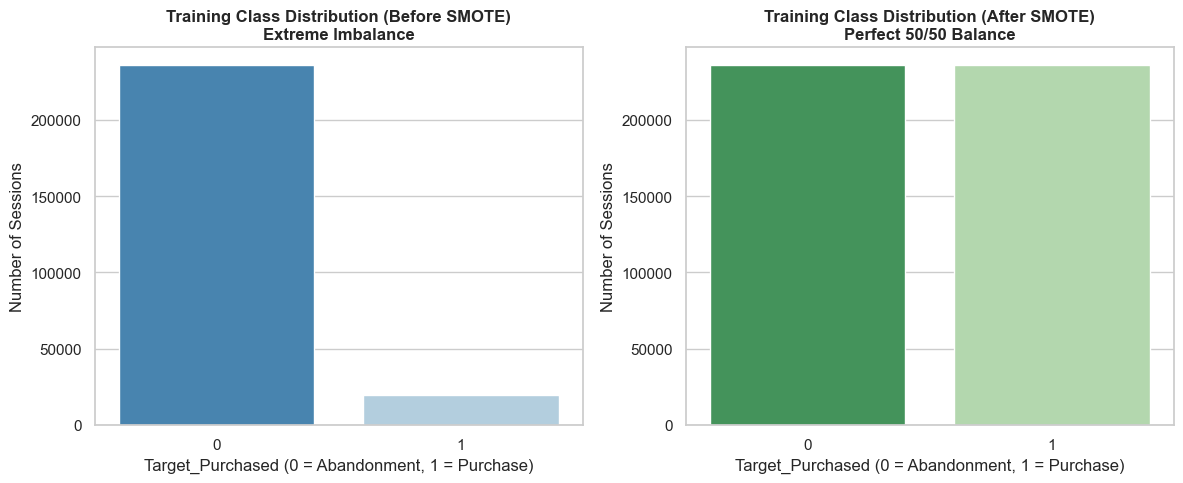

--- Post-SMOTE Statistics ---
Resampled Training set size: 472090
Training Class Balance (After SMOTE):
Target_Purchased
0    50.0
1    50.0
Name: proportion, dtype: float64


In [2]:
import pandas as pd
import os
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# --- NEW IMPORTS FOR VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the optimized dataset
data_path = "data/processed/computer_sales_processed.csv"
df = pd.read_csv(data_path)

# 2. Encode the Categorical Variable (Brand_Affinity)
# Scikit-learn's Decision Tree requires all inputs to be numeric matrix formats.
le_brand = LabelEncoder()
df['Brand_Encoded'] = le_brand.fit_transform(df['Brand_Affinity'])

# Save the encoder for the FastAPI backend artifact registry
os.makedirs("models", exist_ok=True)
joblib.dump(le_brand, "models/brand_encoder.joblib")

# 3. Define Features (X) and Target (y)
feature_cols = ['Session_Duration', 'Product_Views', 'Cart_Additions', 'Max_Price', 'Brand_Encoded']
X = df[feature_cols]
y = df['Target_Purchased']

# 4. Train/Test Split (80% Training, 20% Testing)
# stratify=y ensures the 80/20 split maintains the exact ratio of buyers/non-buyers
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data Split Statistics ---")
print(f"Original Training set size: {len(X_train)}")
print(f"Original Testing set size: {len(X_test)}")
print(f"Training Class Imbalance (Before SMOTE):\n{y_train.value_counts(normalize=True) * 100}\n")

# 5. Apply SMOTE to the Training Data ONLY
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("--- Post-SMOTE Statistics ---")
print(f"Resampled Training set size: {len(X_train_resampled)}")
print(f"Training Class Balance (After SMOTE):\n{y_train_resampled.value_counts(normalize=True) * 100}\n")

# 6. VISUALIZE BEFORE AND AFTER SMOTE (Added for Report Screenshot)
# Set professional academic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Before SMOTE
sns.countplot(x=y_train, ax=axes[0], palette="Blues_r")
axes[0].set_title("Training Class Distribution (Before SMOTE)\nExtreme Imbalance", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Target_Purchased (0 = Abandonment, 1 = Purchase)")
axes[0].set_ylabel("Number of Sessions")

# Chart 2: After SMOTE
sns.countplot(x=y_train_resampled, ax=axes[1], palette="Greens_r")
axes[1].set_title("Training Class Distribution (After SMOTE)\nPerfect 50/50 Balance", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Target_Purchased (0 = Abandonment, 1 = Purchase)")
axes[1].set_ylabel("Number of Sessions")

# Adjust layout, save to file, and display
plt.tight_layout()
plt.savefig("smote_imbalance.png", dpi=300) # Automatically saves the high-res image for LaTeX
print("Success: High-resolution visualization saved as 'smote_imbalance.png'")
plt.show() # Pops up on your screen

print("--- Post-SMOTE Statistics ---")
print(f"Resampled Training set size: {len(X_train_resampled)}")
print(f"Training Class Balance (After SMOTE):\n{y_train_resampled.value_counts(normalize=True) * 100}")

## 3. Hyperparameter Optimization & Model Training
Decision Trees are highly susceptible to overfitting, especially when trained on synthetically oversampled data. If left unconstrained, the tree will grow until every leaf node is pure, capturing noise rather than underlying signal.

To enforce mathematical generalization, we deploy **GridSearchCV** with 5-fold cross-validation. This systematically searches through a hyperparameter grid:
* `max_depth`: Restricts the vertical growth of the tree.
* `min_samples_split` & `min_samples_leaf`: Enforces statistical significance by requiring a minimum threshold of samples before allowing a node split.
* `criterion`: Evaluates both Gini impurity and Information Gain (Entropy) to determine the mathematically optimal splitting rule.

**Crucial Pipeline Note:** The GridSearch is explicitly fitted on the `X_train_resampled` dataset to ensure the model learns from the balanced class distribution.

In [3]:
import time

print("Initiating Hyperparameter Tuning via GridSearchCV...")
print("Executing 5-fold cross-validation on the SMOTE-balanced dataset. This may take a few minutes...")
start_time = time.time()

# 1. Define the hyperparameter constraint grid to prevent overfitting
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [10, 50, 100],
    'min_samples_leaf': [5, 20, 50],
    'criterion': ['gini', 'entropy']
}

# 2. Initialize base model
dt_base = DecisionTreeClassifier(random_state=42)

# 3. Run 5-fold cross-validation
# n_jobs=-1 utilizes all available CPU cores to speed up the process
grid_search = GridSearchCV(
    estimator=dt_base, 
    param_grid=param_grid, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

# CRITICAL FIX: Fit on the RESAMPLED data from Cell 2, not the original data!
grid_search.fit(X_train_resampled, y_train_resampled)

# 4. Extract the optimal mathematical model
best_model = grid_search.best_estimator_

elapsed_time = time.time() - start_time
print("✅ Training Complete.")
print(f"Time Elapsed: {elapsed_time:.2f} seconds")
print(f"Optimal Hyperparameters Discovered: {grid_search.best_params_}")

Initiating Hyperparameter Tuning via GridSearchCV...
Executing 5-fold cross-validation on the SMOTE-balanced dataset. This may take a few minutes...
✅ Training Complete.
Time Elapsed: 28.34 seconds
Optimal Hyperparameters Discovered: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 10}


## 4. Model Evaluation, XAI Visualizations & Artifact Serialization
To rigorously evaluate the model's performance and ensure business viability, predictions are generated strictly on the `X_test` subset. This testing data was partitioned prior to the application of SMOTE, ensuring our evaluation reflects true, real-world class imbalance and guarantees zero data leakage.

**Evaluation Framework:**
1.  **Classification Report & Confusion Matrix:** Details False Positives (wasted marketing budget) versus False Negatives (missed conversion opportunities).
2.  **Precision-Recall (PR) Curve:** The gold-standard metric for highly imbalanced datasets, offering a more penalizing and accurate view of performance than traditional ROC curves.
3.  **Explainable AI (XAI) - Feature Importance:** Extracts the weighted Gini importance of each node split to identify the strongest drivers of e-commerce purchasing behavior.
4.  **Artifact Serialization:** The optimally tuned model is exported as a lightweight `.joblib` binary for latency-free API deployment.

--- REAL SYSTEM METRICS (EVALUATED ON UNSEEN DATA) ---
ROC/AUC Score: 0.8360
Precision-Recall AUC Score: 0.4899

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.72      0.83     59012
           1       0.18      0.76      0.30      4882

    accuracy                           0.72     63894
   macro avg       0.58      0.74      0.56     63894
weighted avg       0.91      0.72      0.79     63894



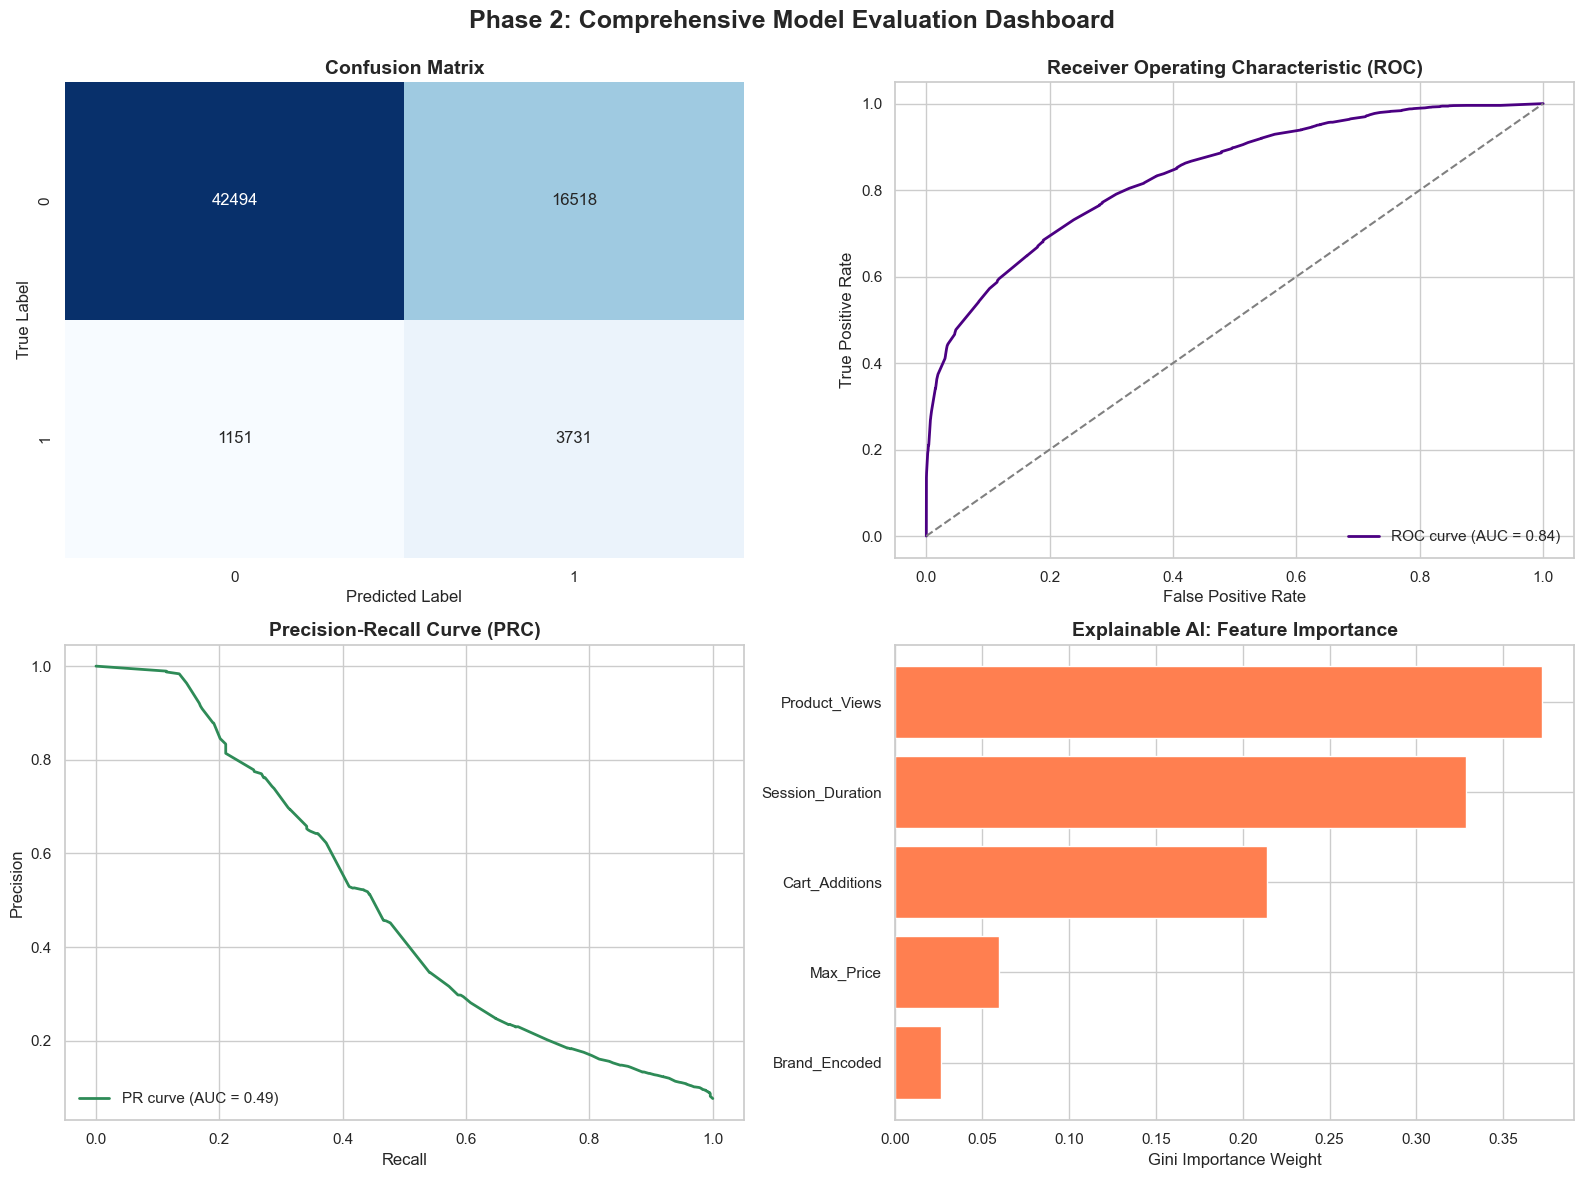


✅ Baseline model serialized and saved successfully to models/decision_tree_v1.joblib


In [4]:
# Generate predictions on the strictly unseen test set
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# 1. Core Mathematical Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(pr_recall, pr_precision)

print("--- REAL SYSTEM METRICS (EVALUATED ON UNSEEN DATA) ---")
print(f"ROC/AUC Score: {auc_score:.4f}")
print(f"Precision-Recall AUC Score: {pr_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 2. XAI & Metric Visualizations (For Final Report)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phase 2: Comprehensive Model Evaluation Dashboard', fontsize=18, fontweight='bold')

# A. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix', fontweight='bold', fontsize=14)
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# B. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0, 1].plot(fpr, tpr, color='indigo', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold', fontsize=14)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')

# C. Precision-Recall Curve
axes[1, 0].plot(pr_recall, pr_precision, color='seagreen', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
axes[1, 0].set_title('Precision-Recall Curve (PRC)', fontweight='bold', fontsize=14)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc='lower left')

# D. Feature Importance (XAI)
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

axes[1, 1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='coral')
axes[1, 1].set_title('Explainable AI: Feature Importance', fontweight='bold', fontsize=14)
axes[1, 1].set_xlabel('Gini Importance Weight')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# 3. Export the trained model for Phase 3 Deployment
joblib.dump(best_model, "models/decision_tree_v1.joblib")
print("\n✅ Baseline model serialized and saved successfully to models/decision_tree_v1.joblib")